In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

print('TensorFlow:', tf.__version__)

/Users/theabood/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow: 2.20.0


In [3]:
base_dir   = '/Users/theabood/Desktop/DataScience/semester3/datasets/products'
train_path = f'{base_dir}/train'
test_path  = f'{base_dir}/test'

IMG_SIZE   = (224, 224)   # MobileNetV2 expects 224x224
BATCH_SIZE = 16           # Small batch since dataset is small
NUM_CLASSES = 6

# Training: simulate bad lighting + standard augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # MobileNetV2 specific preprocessing
    brightness_range=[0.3, 1.0],               # Simulate dark/bad lighting
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Test: only preprocessing, no augmentation
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

training_set = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(training_set.class_indices.keys())
print('Classes:', class_names)
print('Train  :', training_set.samples, 'images')
print('Test   :', test_set.samples, 'images')

Found 597 images belonging to 6 classes.
Found 144 images belonging to 6 classes.
Classes: ['blue_boost', 'pepsi', 'purple_boost', 'quavers', 'red_boost', 'tuna_sandwhich']
Train  : 597 images
Test   : 144 images


In [4]:
# ── Load pretrained MobileNetV2 (without top classification layer) ────────────
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False   # Freeze all base layers for Phase 1

# ── Add custom classification head ───────────────────────────────────────────
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Total layers     : {len(model.layers)}')
print(f'Trainable layers : {len([l for l in model.layers if l.trainable])}')

Total layers     : 161
Trainable layers : 7


In [5]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print('=== Phase 1: Training classification head only ===')
history1 = model.fit(
    training_set,
    epochs=10,
    validation_data=test_set,
    callbacks=[early_stop]
)

=== Phase 1: Training classification head only ===


/Users/theabood/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.4910 - loss: 1.3507 - val_accuracy: 0.9375 - val_loss: 0.2245
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.8924 - loss: 0.2628 - val_accuracy: 0.9861 - val_loss: 0.0905
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9703 - loss: 0.1080 - val_accuracy: 0.9861 - val_loss: 0.0528
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9756 - loss: 0.0758 - val_accuracy: 0.9861 - val_loss: 0.0434
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9688 - loss: 0.0992 - val_accuracy: 1.0000 - val_loss: 0.0180
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9801 - loss: 0.0656 - val_accuracy: 0.9931 - val_loss: 0.0176
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.9874 - loss: 0.0433 - val_accuracy: 0.9931 - val_loss: 0.0152
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.9919 - loss: 0.0338 - val_accuracy: 1.0000 - val_loss:

In [6]:
# Unfreeze the last 30 layers of MobileNetV2 for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower learning rate to avoid destroying pretrained weights
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Trainable layers after unfreezing: {len([l for l in model.layers if l.trainable])}')

early_stop2 = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

print('\n=== Phase 2: Fine-tuning top layers ===')
history2 = model.fit(
    training_set,
    epochs=30,
    validation_data=test_set,
    callbacks=[early_stop2, reduce_lr]
)

Trainable layers after unfreezing: 37

=== Phase 2: Fine-tuning top layers ===
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.9558 - loss: 0.0959 - val_accuracy: 0.9931 - val_loss: 0.0346 - learning_rate: 1.0000e-04
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9727 - loss: 0.0832 - val_accuracy: 1.0000 - val_loss: 0.0075 - learning_rate: 1.0000e-04
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9757 - loss: 0.0675 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 1.0000e-04
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9850 - loss: 0.0463 - val_accuracy: 1.0000 - val_loss: 0.0070 - learning_rate: 1.0000e-04
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9830 - loss: 0.0461 - val_accuracy: 1.0000 - val_loss: 0.0036 - learning_rate: 1.0000e-04
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9907 - loss: 0.0346
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.9999998736893

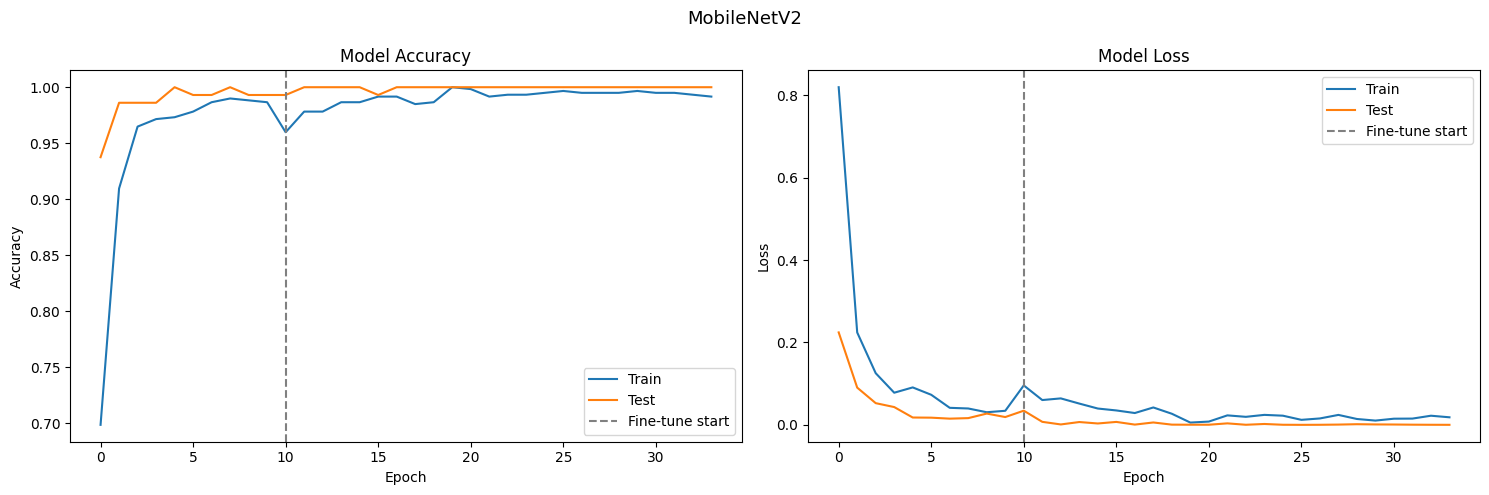

In [7]:
# Combine both phases
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
phase1_end = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, train_vals, val_vals, title, ylabel in zip(
    axes,
    [acc, loss],
    [val_acc, val_loss],
    ['Model Accuracy', 'Model Loss'],
    ['Accuracy', 'Loss']
):
    ax.plot(train_vals, label='Train')
    ax.plot(val_vals,   label='Test')
    ax.axvline(x=phase1_end, color='gray', linestyle='--', label='Fine-tune start')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.suptitle('MobileNetV2', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
test_set.reset()
true_labels      = test_set.classes
predicted_probs  = model.predict(test_set)
predicted_labels = np.argmax(predicted_probs, axis=1)

accuracy = np.mean(predicted_labels == true_labels) * 100
print(f'\n✅ Test Accuracy: {accuracy:.2f}%')
print('\n📊 Classification Report:')
print(classification_report(true_labels, predicted_labels, target_names=class_names))

9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 630ms/step

✅ Test Accuracy: 100.00%

📊 Classification Report:
                precision    recall  f1-score   support

    blue_boost       1.00      1.00      1.00        24
         pepsi       1.00      1.00      1.00        24
  purple_boost       1.00      1.00      1.00        24
       quavers       1.00      1.00      1.00        24
     red_boost       1.00      1.00      1.00        24
tuna_sandwhich       1.00      1.00      1.00        24

      accuracy                           1.00       144
     macro avg       1.00      1.00      1.00       144
  weighted avg       1.00      1.00      1.00       144



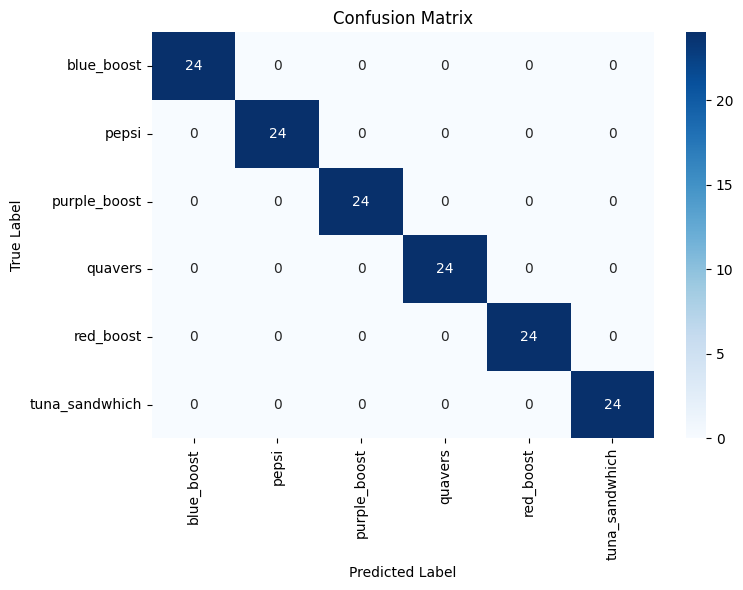

In [9]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()